# Density approximation of $V_Y$

In [1]:
from pearsondist import Pearson8, Support8

from utils import plot_pdf_cdf, plot_dpdf_pdf
from joint_mom import comp_joint_moms_mat
from joint_mom_tr import joint_mom_tr, joint_mom_tr_row, index
import numpy as np

In [2]:
jointMomRow = np.loadtxt('hest2_mu_vy_row.txt', delimiter=' ', dtype=float).tolist()

In [3]:
degree = 4
mu_d1 = [joint_mom_tr_row(i, 0, jointMomRow) for i in range(1, 2*degree + 1)]
mu_x2 = [jointMomRow[index(0, i)] for i in range(1, 2*degree + 1)]
mu_d2 = [joint_mom_tr_row(0, i, jointMomRow) for i in range(1, 2*degree + 1)]
mu_d1d2 = [[joint_mom_tr_row(i, j, jointMomRow) for j in range(degree + 1)] for i in range(degree + 1)]

## Pearson Density Approximation ($\zeta_1 = x_1$): $V_t$

{'A1': np.float64(116165.24253397596),
 'A2': np.float64(0.639999999999998),
 'A3': np.float64(-116165.88253397598),
 'B3': np.float64(20225307942.412636),
 'type': 44,
 'x1': np.float64(-87359.95051391),
 'x2': np.float64(2.3314683436353133e-17),
 'x3': np.complex128(43373.82837108309+75451.77203450307j)}
a = 0.16000000048503848, scale = 104581.40526727936
is_max: False
pdf(-a) = 1.0000000


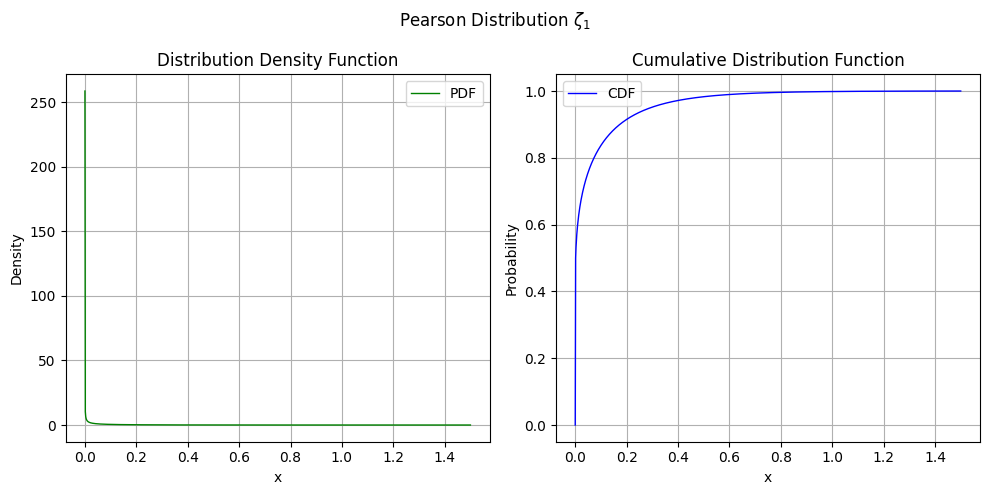

pdf(0.0000100) = 2.59e+02, pdf(1.5000000) = 3.12e-04


In [9]:
from pprint import pprint

pearson = Pearson8(mu_d1)
pprint(pearson.pfd) # print(pearson.mom)
print(f'a = {pearson.coef[0]}, scale = {pearson.pdf_obj.scale}') # print("coef: ", pearson.coef)
print(f'is_max: {pearson.pdf_obj.is_max}')
print(f'pdf(-a) = {pearson.pdf(-pearson.coef[0]):.7f}')
# lbub = pearson.determine_bounds()

lbub = (0.00001, 1.5)
# lbub = (-0.05, 0.3)
x = np.linspace(lbub[0], lbub[1], 1000)

pdf = pearson.pdf(x); title = r'Pearson Distribution $\zeta_1$'
plot_pdf_cdf(x, pdf, title)
dpdf = pearson.dpdf(x); title = 'PDF and its Derivative'
# support8 = Support8(pearson.pdf_obj)
# bounds = support8.determine_bounds()
# print(f'bounds: ({bounds[0]:.5f},{bounds[1]:.5f})')

# roots = support8.pdf_obj.ddpdf_roots()
# plot_dpdf_pdf(x, dpdf, pdf, title, roots)

print(f'pdf({lbub[0]:.7f}) = {pearson.pdf(lbub[0]):.2e}, pdf({lbub[1]:.7f}) = {pearson.pdf(lbub[1]):.2e}')

## Pearson Density Approximation ($x_2$): $Y_t$

{'A1': np.float64(1.7291196564489215),
 'A2': np.float64(-7.4552574511606595),
 'A3': np.float64(5.726137794712042),
 'B3': np.float64(-0.6017182718136644),
 'type': 44,
 'x1': np.float64(-69.16847201247384),
 'x2': np.float64(-14.64483075412621),
 'x3': np.complex128(0.9623676227794197+1.18231804745929j)}
a = -0.26182489827224625, scale = 13.21102487897968
iteration: 0, x0 =   -0.7581654
iteration: 1, x0 =   -1.3657675
iteration: 2, x0 =   -1.9303522
iteration: 3, x0 =   -2.5004373
iteration: 4, x0 =   -3.0878873
iteration: 5, x0 =   -3.6954436
iteration: 6, x0 =   -4.3216771
iteration: 7, x0 =   -4.9626657
iteration: 8, x0 =   -5.6128548
iteration: 0, x0 =    1.2705865
iteration: 1, x0 =    1.5189365
iteration: 2, x0 =    1.7512668
iteration: 3, x0 =    1.9873604
iteration: 4, x0 =    2.2387408
iteration: 5, x0 =    2.5150714
iteration: 6, x0 =    2.8263199
iteration: 7, x0 =    3.1840397
iteration: 8, x0 =    3.6025639
iteration: 9, x0 =    4.1004876
iteration: 10, x0 =    4.7027919

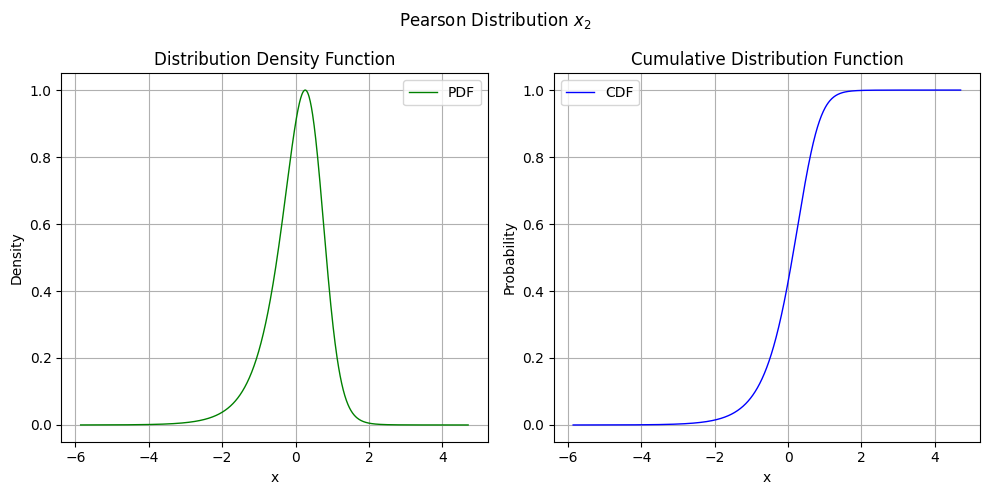

iteration: 0, x0 =   -0.7581654
iteration: 1, x0 =   -1.3657675
iteration: 2, x0 =   -1.9303522
iteration: 3, x0 =   -2.5004373
iteration: 4, x0 =   -3.0878873
iteration: 5, x0 =   -3.6954436
iteration: 6, x0 =   -4.3216771
iteration: 7, x0 =   -4.9626657
iteration: 8, x0 =   -5.6128548
iteration: 0, x0 =    1.2705865
iteration: 1, x0 =    1.5189365
iteration: 2, x0 =    1.7512668
iteration: 3, x0 =    1.9873604
iteration: 4, x0 =    2.2387408
iteration: 5, x0 =    2.5150714
iteration: 6, x0 =    2.8263199
iteration: 7, x0 =    3.1840397
iteration: 8, x0 =    3.6025639
iteration: 9, x0 =    4.1004876
iteration: 10, x0 =    4.7027919


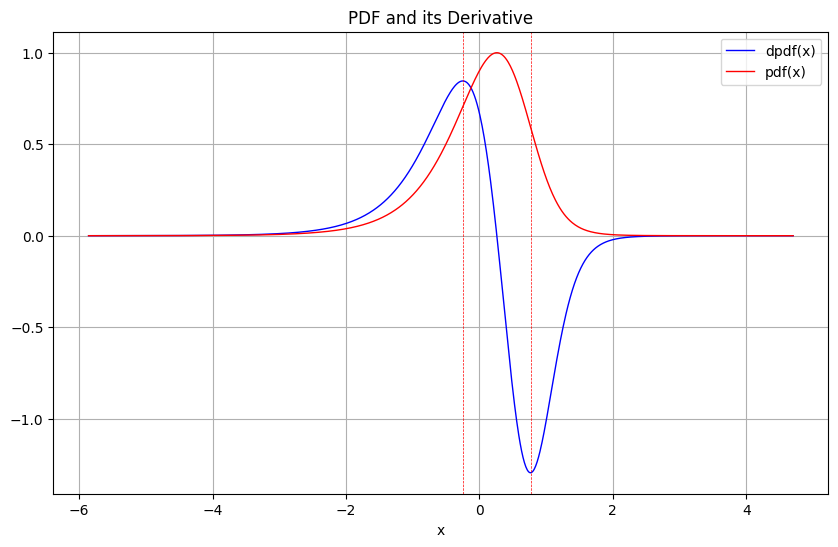

pdf(-5.8581172) = 7.86e-05, pdf(4.7027919) = 8.80e-06


In [5]:
from pearsondist.pearson8 import Pearson8

pearson = Pearson8(mu_x2)

pprint(pearson.pfd) # print(pearson.mom)
print(f'a = {pearson.coef[0]}, scale = {pearson.pdf_obj.scale}') # print("coef: ", pearson.coef)
lbub = pearson.determine_bounds()

# lbub = (-1.8, 1.0)
x = np.linspace(lbub[0], lbub[1], 1000)

# txt = ','.join(f'{mu_:.9f}' for mu_ in mu_x2); print(f'mu_x2 = [{txt}]')

pdf = pearson.pdf(x); title = r'Pearson Distribution $x_2$'
plot_pdf_cdf(x, pdf, title)

dpdf = pearson.dpdf(x); title = 'PDF and its Derivative'
support8 = Support8(pearson.pdf_obj); roots = support8.pdf_obj.ddpdf_roots()
plot_dpdf_pdf(x, dpdf, pdf, title, roots)

print(f'pdf({lbub[0]:.7f}) = {pearson.pdf(lbub[0]):.2e}, pdf({lbub[1]:.7f}) = {pearson.pdf(lbub[1]):.2e}')

## Pearson Density Approximation ($\zeta_2$): $Y_t + c V_t$

The transformed variable $\zeta_2 = Y_t + c V_t$,

$c = -\frac{\mathrm{cov}(I_t, dI\!E_t)}{\mathrm{var}(I_t)} = -0.2825008$

$\mathrm{cov}(\zeta_1, \zeta_2) = \mathrm{cov}(I_t, dI\!E_t + c I_t) = \mathrm{cov}(I_t, dI\!E_t) + c \times\mathrm{var}(I_t) = 0$

{'A1': np.float64(-5.106581961983084),
 'A2': np.float64(-1.0350063339326494),
 'A3': np.float64(6.1415882959157715),
 'B3': np.float64(-1.174223898543726),
 'type': 44,
 'x1': np.float64(-12.260837720226924),
 'x2': np.float64(70.70059080202574),
 'x3': np.complex128(0.9556819738566277+1.2352292082974743j)}
a = -0.31461177980275923, scale = 17.12128800762503
iteration: 0, x0 =   -0.6982257
iteration: 1, x0 =   -1.2833457
iteration: 2, x0 =   -1.8280904
iteration: 3, x0 =   -2.3798815
iteration: 4, x0 =   -2.9510712
iteration: 5, x0 =   -3.5449054
iteration: 6, x0 =   -4.1601333
iteration: 7, x0 =   -4.7924761
iteration: 8, x0 =   -5.4353531
iteration: 0, x0 =    1.3185383
iteration: 1, x0 =    1.5805814
iteration: 2, x0 =    1.8245468
iteration: 3, x0 =    2.0714097
iteration: 4, x0 =    2.3327383
iteration: 5, x0 =    2.6177486
iteration: 6, x0 =    2.9354844
iteration: 7, x0 =    3.2959260
iteration: 8, x0 =    3.7108440
iteration: 9, x0 =    4.1946881
iteration: 10, x0 =    4.76568

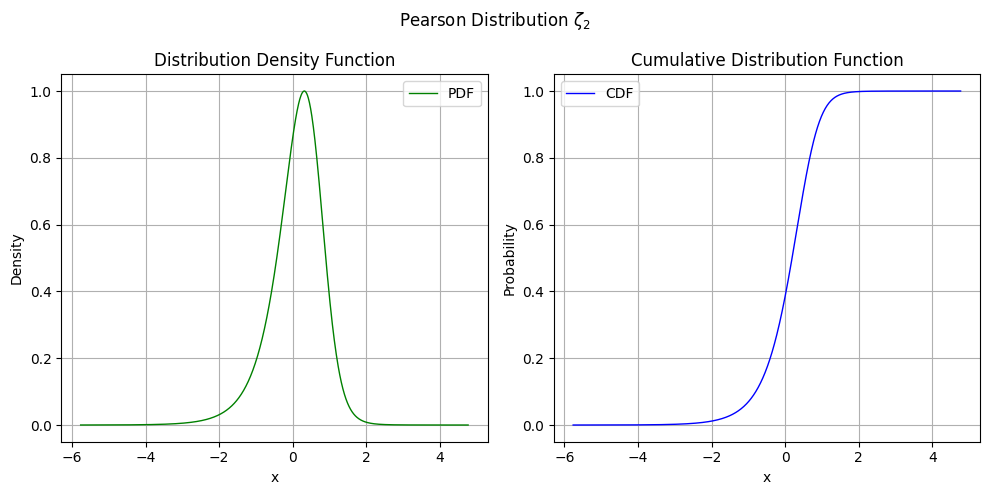

iteration: 0, x0 =   -0.6982257
iteration: 1, x0 =   -1.2833457
iteration: 2, x0 =   -1.8280904
iteration: 3, x0 =   -2.3798815
iteration: 4, x0 =   -2.9510712
iteration: 5, x0 =   -3.5449054
iteration: 6, x0 =   -4.1601333
iteration: 7, x0 =   -4.7924761
iteration: 8, x0 =   -5.4353531
iteration: 0, x0 =    1.3185383
iteration: 1, x0 =    1.5805814
iteration: 2, x0 =    1.8245468
iteration: 3, x0 =    2.0714097
iteration: 4, x0 =    2.3327383
iteration: 5, x0 =    2.6177486
iteration: 6, x0 =    2.9354844
iteration: 7, x0 =    3.2959260
iteration: 8, x0 =    3.7108440
iteration: 9, x0 =    4.1946881
iteration: 10, x0 =    4.7656823


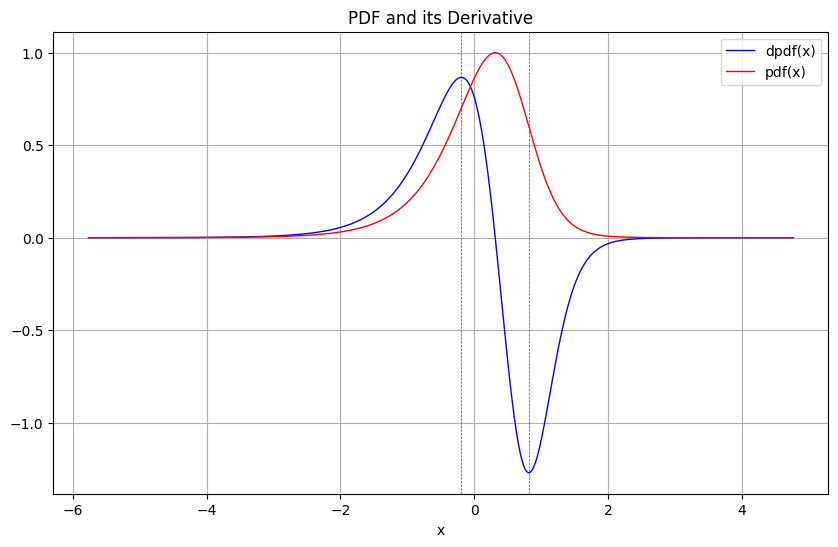

pdf(-5.7624128) = 6.80e-05, pdf(4.7656823) = 9.07e-06


In [6]:
pearson = Pearson8(mu_d2)
pprint(pearson.pfd)
print(f'a = {pearson.coef[0]}, scale = {pearson.pdf_obj.scale}') # print("coef: ", pearson.coef)
lbub = pearson.determine_bounds()

# lbub = (-1.778969, 0.95)
print(f'lbub: {lbub}')
x = np.linspace(lbub[0], lbub[1], 1000)

pdf = pearson.pdf(x); title = r'Pearson Distribution $\zeta_2$'
plot_pdf_cdf(x, pdf, title)

dpdf = pearson.dpdf(x); title = 'PDF and its Derivative'
support8 = Support8(pearson.pdf_obj); roots = support8.pdf_obj.ddpdf_roots()
plot_dpdf_pdf(x, dpdf, pdf, title, roots)

print(f'pdf({lbub[0]:.7f}) = {pearson.pdf(lbub[0]):.2e}, pdf({lbub[1]:.7f}) = {pearson.pdf(lbub[1]):.2e}')